<a href="https://colab.research.google.com/github/AlvaroSepul/Entrega-3/blob/main/Entrega3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**🛠️ Preparación de los Datos**


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Cargar archivo limpio
# =========================
df = pd.read_csv("TelecomX_Data_limpio.csv")

print("Primeras filas:")
print(df.head())

print("\nColumnas:")
print(df.columns.tolist())


# =========================
# 2. Eliminar columnas que no aportan
# =========================
# Se elimina el identificador único del cliente
columnas_eliminar = ["ID_Cliente"]

for col in columnas_eliminar:
    if col in df.columns:
        df = df.drop(columns=col)

print("\nColumnas después de eliminar ID:")
print(df.columns.tolist())


# =========================
# 3. Definir variable objetivo
# =========================
# Abandono será la variable a predecir
# Si por algún motivo viene como texto, se transforma a 0 y 1
if df["Abandono"].dtype == "object":
    df["Abandono"] = df["Abandono"].astype(str).str.strip().map({"Yes": 1, "No": 0})

# Separar variables predictoras y objetivo
X = df.drop(columns="Abandono")
y = df["Abandono"]

print("\nTamaño de X:", X.shape)
print("Tamaño de y:", y.shape)


# =========================
# 4. Transformar variables categóricas
# =========================
# Identificar columnas categóricas
columnas_categoricas = X.select_dtypes(include="object").columns.tolist()
print("\nColumnas categóricas:")
print(columnas_categoricas)

# One-hot encoding
X_encoded = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)

print("\nDimensiones después de encoding:")
print(X_encoded.shape)


# =========================
# 5. Revisar proporción de clases
# =========================
conteo_clases = y.value_counts().sort_index()
proporcion_clases = (y.value_counts(normalize=True).sort_index() * 100).round(2)

print("\nConteo de clases:")
print(conteo_clases)

print("\nProporción de clases (%):")
print(proporcion_clases)

# Mostrar de forma más clara
print(f"\nClientes que permanecen: {conteo_clases.get(0, 0)} ({proporcion_clases.get(0, 0)}%)")
print(f"Clientes que cancelan: {conteo_clases.get(1, 0)} ({proporcion_clases.get(1, 0)}%)")

# Evaluación simple del desbalance
if proporcion_clases.min() < 40:
    print("\nHay desbalance entre las clases.")
else:
    print("\nNo se observa un desbalance severo entre las clases.")


# =========================
# 6. Separar entrenamiento y prueba
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)


# =========================
# 7. Escalado para modelos sensibles a la escala
# =========================
# Esta versión sirve para:
# KNN, SVM, Regresión Logística, Redes Neuronales

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Columnas numéricas continuas a escalar
columnas_escalar = [col for col in ["Adulto_Mayor", "Meses_Cliente", "Cargo_Mensual", "Cargo_Total", "Cuentas_Diarias"] if col in X_train.columns]

scaler = StandardScaler()

X_train_scaled[columnas_escalar] = scaler.fit_transform(X_train[columnas_escalar])
X_test_scaled[columnas_escalar] = scaler.transform(X_test[columnas_escalar])

print("\nColumnas escaladas:")
print(columnas_escalar)


# =========================
# 8. Versiones finales para modelado
# =========================
# Para modelos basados en árboles:
X_train_arbol = X_train.copy()
X_test_arbol = X_test.copy()

# Para modelos sensibles a la escala:
X_train_modelos_escala = X_train_scaled.copy()
X_test_modelos_escala = X_test_scaled.copy()

print("\nPreparación de datos finalizada.")
print("Datos para árboles:", X_train_arbol.shape, X_test_arbol.shape)
print("Datos escalados:", X_train_modelos_escala.shape, X_test_modelos_escala.shape)

Primeras filas:
   ID_Cliente  Abandono     Genero  Adulto_Mayor  Pareja  Dependientes  \
0  0002-ORFBO         0   Femenino             0       1             1   
1  0003-MKNFE         0  Masculino             0       0             0   
2  0004-TLHLJ         1  Masculino             0       0             0   
3  0011-IGKFF         1  Masculino             1       1             0   
4  0013-EXCHZ         1   Femenino             1       1             0   

   Meses_Cliente phone.PhoneService phone.MultipleLines  \
0              9                Yes                  No   
1              9                Yes                 Yes   
2              4                Yes                  No   
3             13                Yes                  No   
4              3                Yes                  No   

  internet.InternetService  ... internet.DeviceProtection  \
0                      DSL  ...                        No   
1                      DSL  ...                        No   
2

##🎯 Correlación y Selección de Variables

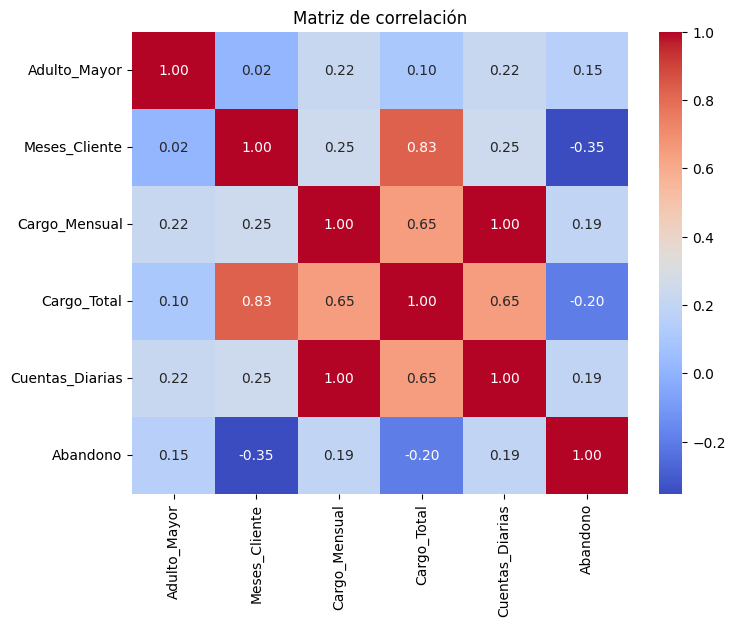

Correlación con Abandono:
Abandono           1.000000
Cuentas_Diarias    0.193412
Cargo_Mensual      0.193356
Adulto_Mayor       0.150889
Cargo_Total       -0.198324
Meses_Cliente     -0.352229
Name: Abandono, dtype: float64


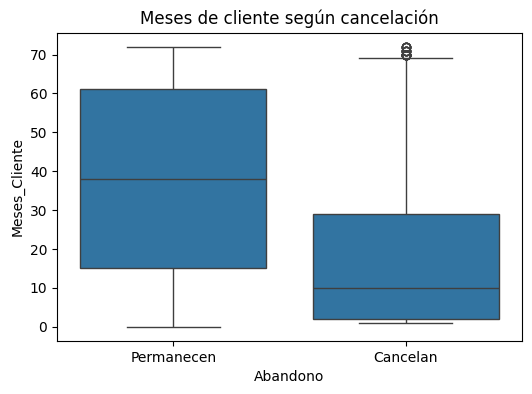

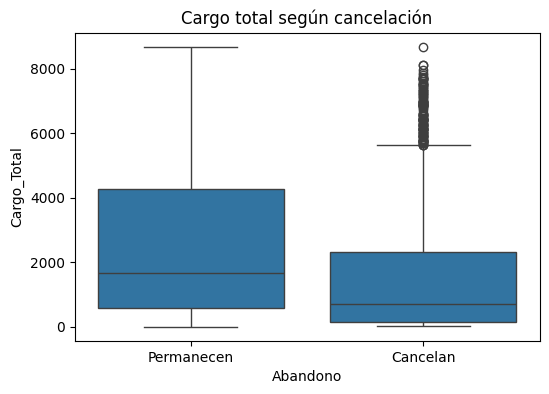

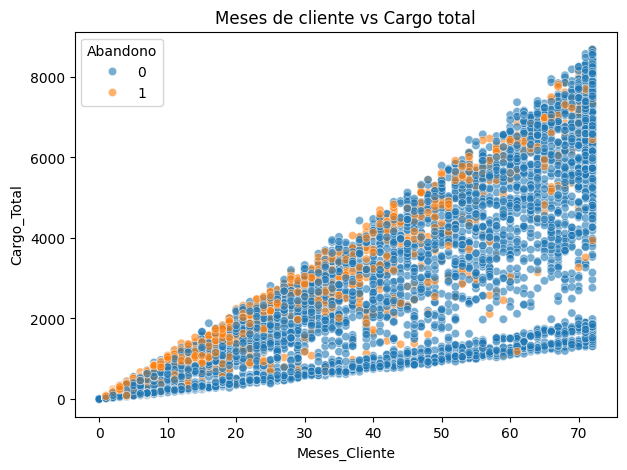

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# =========================
# 1. Matriz de correlación
# =========================

variables_numericas = ["Adulto_Mayor", "Meses_Cliente", "Cargo_Mensual", "Cargo_Total", "Cuentas_Diarias", "Abandono"]
df_corr = df[variables_numericas]

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

# Ver correlación con Abandono en forma ordenada
corr_abandono = df_corr.corr()["Abandono"].sort_values(ascending=False)
print("Correlación con Abandono:")
print(corr_abandono)


# =========================
# 2. Tiempo de contrato x Cancelación
# =========================

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Abandono", y="Meses_Cliente")
plt.title("Meses de cliente según cancelación")
plt.xlabel("Abandono")
plt.ylabel("Meses_Cliente")
plt.xticks([0, 1], ["Permanecen", "Cancelan"])
plt.show()


# =========================
# 3. Gasto total x Cancelación
# =========================

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Abandono", y="Cargo_Total")
plt.title("Cargo total según cancelación")
plt.xlabel("Abandono")
plt.ylabel("Cargo_Total")
plt.xticks([0, 1], ["Permanecen", "Cancelan"])
plt.show()


# =========================
# 4. Scatter plot opcional
# =========================

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Meses_Cliente", y="Cargo_Total", hue="Abandono", alpha=0.6)
plt.title("Meses de cliente vs Cargo total")
plt.xlabel("Meses_Cliente")
plt.ylabel("Cargo_Total")
plt.show()

###🤖 Modelado Predictivo

Dimensiones de X: (7043, 31)
Dimensiones de y: (7043,)

Conteo de clases:
Abandono
0    5174
1    1869
Name: count, dtype: int64

Proporción de clases (%):
Abandono
0    73.46
1    26.54
Name: proportion, dtype: float64

Permanecen: 5174 (73.46%)
Cancelan: 1869 (26.54%)

Tamaño entrenamiento: (5634, 31)
Tamaño prueba: (1409, 31)

===== Regresión Logística =====
Accuracy: 0.7928
Precision: 0.6331
Recall: 0.5214
F1-score: 0.5718
Matriz de confusión:
[[922 113]
 [179 195]]


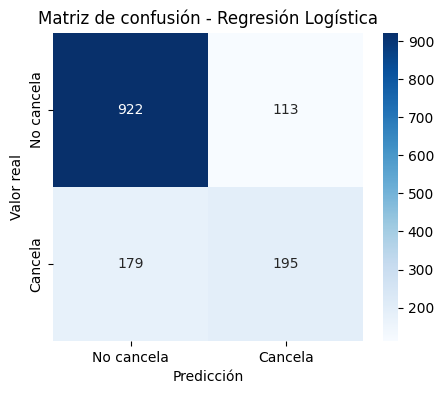


===== Random Forest =====
Accuracy: 0.7786
Precision: 0.6062
Recall: 0.4733
F1-score: 0.5315
Matriz de confusión:
[[920 115]
 [197 177]]


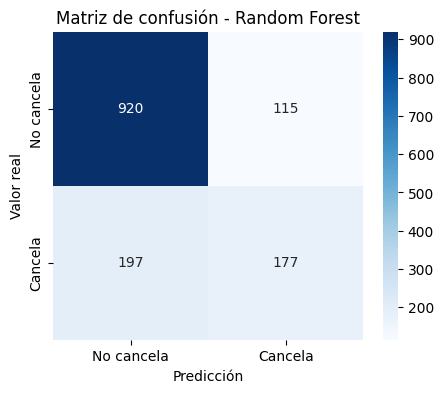


===== Comparación entrenamiento vs prueba =====
Regresión Logística - Train: 0.8099 | Test: 0.7928
Random Forest      - Train: 0.9977 | Test: 0.7786

Resumen de resultados:
                Modelo  Accuracy  Precision  Recall  F1-score  Accuracy_Train  \
0  Regresión Logística    0.7928     0.6331  0.5214    0.5718          0.8099   
1        Random Forest    0.7786     0.6062  0.4733    0.5315          0.9977   

   Accuracy_Test  
0         0.7928  
1         0.7786  


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# =========================
# 1. Preparación para modelado
# =========================

df_modelo = df.copy()

# Eliminar identificador único
if "ID_Cliente" in df_modelo.columns:
    df_modelo = df_modelo.drop(columns=["ID_Cliente"])

# Asegurar que Abandono sea numérico
if df_modelo["Abandono"].dtype == "object":
    df_modelo["Abandono"] = df_modelo["Abandono"].astype(str).str.strip().map({"Yes": 1, "No": 0})

# Separar variables predictoras y variable objetivo
X = df_modelo.drop(columns=["Abandono"])
y = df_modelo["Abandono"]

# Convertir variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# =========================
# 2. Proporción de clases
# =========================

conteo_clases = y.value_counts().reindex([0, 1], fill_value=0)
proporcion_clases = (y.value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100).round(2)

print("\nConteo de clases:")
print(conteo_clases)

print("\nProporción de clases (%):")
print(proporcion_clases)

print(f"\nPermanecen: {conteo_clases[0]} ({proporcion_clases[0]}%)")
print(f"Cancelan: {conteo_clases[1]} ({proporcion_clases[1]}%)")

# =========================
# 3. División entrenamiento / prueba
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

# =========================
# 4. Normalización para Regresión Logística
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 5. Modelo 1: Regresión Logística
# =========================

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)

# =========================
# 6. Modelo 2: Random Forest
# =========================

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

# =========================
# 7. Función de evaluación
# =========================

def evaluar_modelo(nombre, y_real, y_pred):
    acc = accuracy_score(y_real, y_pred)
    prec = precision_score(y_real, y_pred)
    rec = recall_score(y_real, y_pred)
    f1 = f1_score(y_real, y_pred)
    cm = confusion_matrix(y_real, y_pred)

    print(f"\n===== {nombre} =====")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1-score:", round(f1, 4))
    print("Matriz de confusión:")
    print(cm)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No cancela", "Cancela"],
        yticklabels=["No cancela", "Cancela"]
    )
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.show()

# =========================
# 8. Evaluar modelos
# =========================

evaluar_modelo("Regresión Logística", y_test, y_pred_lr)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

# =========================
# 9. Comparar train vs test
# =========================

acc_train_lr = modelo_lr.score(X_train_scaled, y_train)
acc_test_lr = modelo_lr.score(X_test_scaled, y_test)

acc_train_rf = modelo_rf.score(X_train, y_train)
acc_test_rf = modelo_rf.score(X_test, y_test)

print("\n===== Comparación entrenamiento vs prueba =====")
print("Regresión Logística - Train:", round(acc_train_lr, 4), "| Test:", round(acc_test_lr, 4))
print("Random Forest      - Train:", round(acc_train_rf, 4), "| Test:", round(acc_test_rf, 4))

# =========================
# 10. Resumen simple
# =========================

resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "Accuracy_Train": [acc_train_lr, acc_train_rf],
    "Accuracy_Test": [acc_test_lr, acc_test_rf]
}).round(4)

print("\nResumen de resultados:")
print(resultados)

##📋 Interpretación y Conclusiones


Variables más relevantes - Regresión Logística
                                Variable  Coeficiente  Impacto_Absoluto
3                          Meses_Cliente    -1.421896          1.421896
5                            Cargo_Total     0.692948          0.692948
11  internet.InternetService_Fiber optic     0.597681          0.597681
26                Tipo_Contrato_Two year    -0.582858          0.582858
4                          Cargo_Mensual    -0.319026          0.319026
25                Tipo_Contrato_One year    -0.280053          0.280053
6                        Cuentas_Diarias    -0.279346          0.279346
22              internet.StreamingTV_Yes     0.206159          0.206159
10               phone.MultipleLines_Yes     0.198884          0.198884
29          Metodo_Pago_Electronic check     0.190367          0.190367


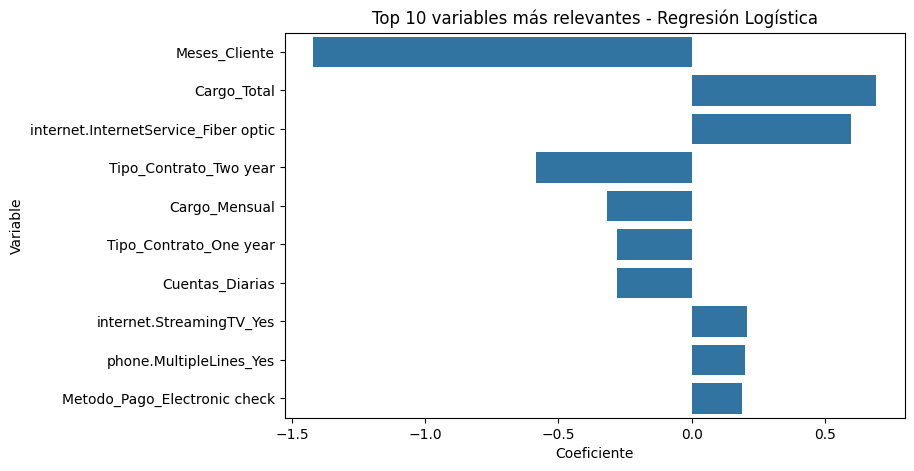


Variables más relevantes - Random Forest
                                Variable  Importancia
5                            Cargo_Total     0.166404
3                          Meses_Cliente     0.162725
4                          Cargo_Mensual     0.134332
6                        Cuentas_Diarias     0.117869
29          Metodo_Pago_Electronic check     0.035988
26                Tipo_Contrato_Two year     0.034697
11  internet.InternetService_Fiber optic     0.033863
7                       Genero_Masculino     0.025118
27          account.PaperlessBilling_Yes     0.023436
14           internet.OnlineSecurity_Yes     0.022589


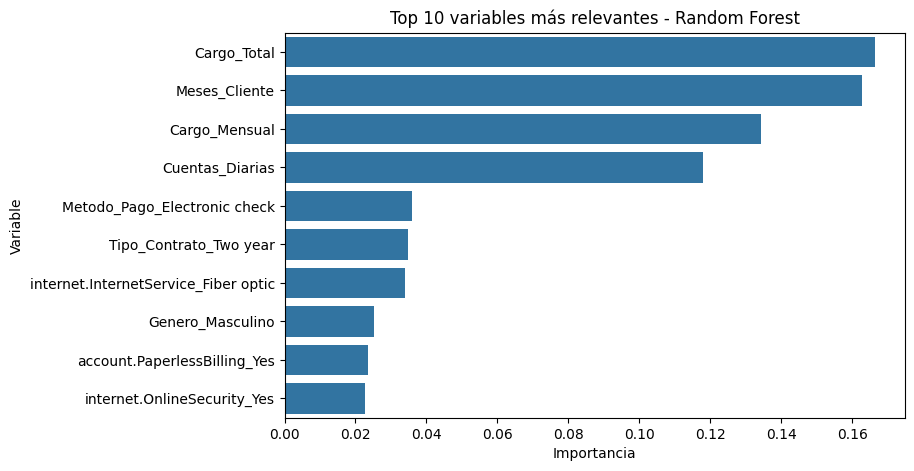


Top 5 Regresión Logística:
                                Variable  Coeficiente
3                          Meses_Cliente    -1.421896
5                            Cargo_Total     0.692948
11  internet.InternetService_Fiber optic     0.597681
26                Tipo_Contrato_Two year    -0.582858
4                          Cargo_Mensual    -0.319026

Top 5 Random Forest:
                        Variable  Importancia
5                    Cargo_Total     0.166404
3                  Meses_Cliente     0.162725
4                  Cargo_Mensual     0.134332
6                Cuentas_Diarias     0.117869
29  Metodo_Pago_Electronic check     0.035988


In [5]:
# =========================
# 11. Variables más relevantes - Regresión Logística
# =========================

# Obtener nombres de variables después del one-hot encoding
feature_names = X.columns

# Coeficientes de la regresión logística
coef_lr = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": modelo_lr.coef_[0]
})

# Ordenar de mayor a menor impacto absoluto
coef_lr["Impacto_Absoluto"] = coef_lr["Coeficiente"].abs()
coef_lr = coef_lr.sort_values("Impacto_Absoluto", ascending=False)

print("\nVariables más relevantes - Regresión Logística")
print(coef_lr.head(10))

# Gráfico top 10
plt.figure(figsize=(8,5))
sns.barplot(data=coef_lr.head(10), x="Coeficiente", y="Variable")
plt.title("Top 10 variables más relevantes - Regresión Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()


# =========================
# 12. Variables más relevantes - Random Forest
# =========================

importancia_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
}).sort_values("Importancia", ascending=False)

print("\nVariables más relevantes - Random Forest")
print(importancia_rf.head(10))

# Gráfico top 10
plt.figure(figsize=(8,5))
sns.barplot(data=importancia_rf.head(10), x="Importancia", y="Variable")
plt.title("Top 10 variables más relevantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


# =========================
# 13. Resumen de factores principales
# =========================

top_lr = coef_lr.head(5)[["Variable", "Coeficiente"]]
top_rf = importancia_rf.head(5)[["Variable", "Importancia"]]

print("\nTop 5 Regresión Logística:")
print(top_lr)

print("\nTop 5 Random Forest:")
print(top_rf)

## Conclusiones

En general, el análisis mostró que la cancelación de clientes no pasa al azar, sino que está relacionada con ciertas características que se repiten más en quienes terminan dejando el servicio. Tanto en los gráficos como en los modelos se vieron diferencias claras entre los clientes que permanecen y los que cancelan.

Las variables que más influyen están asociadas principalmente al tiempo que lleva el cliente en la empresa, al tipo de contrato y al nivel de gasto. Esto hace pensar que la evasión no depende de una sola causa, sino de una combinación de factores comerciales y de comportamiento.

Además, los modelos permitieron confirmar que sí es posible anticipar, al menos en parte, qué clientes tienen mayor riesgo de cancelar. Esto es importante porque abre la posibilidad de actuar antes, con acciones más enfocadas en los perfiles que muestran mayor probabilidad de abandono.

En resumen, este trabajo ayudó a entender mejor el problema de churn en Telecom X y dejó una base útil para tomar decisiones más informadas, especialmente en temas de retención y fidelización de clientes.